## Evaluate logit ranker outputs
This script plots the results from run_logit_ranker.py

In [15]:
from run_ranker import *

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [17]:
model_dict = {
            'llama3b':'meta-llama/Llama-3.2-3B-Instruct', 
            'tinyllama':'TinyLlama/TinyLlama-1.1B-Chat-v1.0',
            'mistral':"mistralai/Mistral-7B-Instruct-v0.2",
            'qwen':'Qwen/Qwen2.5-7B-Instruct',
            'phi': 'microsoft/Phi-3-mini-128k-instruct',
            'qwen3b':'Qwen/Qwen2.5-3B'}

In [18]:
base_path = '/Users/jessicakahn/Documents/repos/'
item_type = 'music'
# size_of_sample = 10

demo = 'gender'
device = "mps"
log_reg_type = 'reg'
with open('output_data/movie/reverse_title_dict.json', 'r') as file_object:
    reverse_title_dict = json.load(file_object)
with open(f'output_data/{item_type}/processed_data_dict.json', 'r') as file:
    data_dict = json.load(file)
with open(f'output_data/{item_type}/gender_dict.json','r') as file:
    gender_dict = json.load(file)

In [19]:
model_name = 'llama3b'

In [20]:
# output_data/music/logit_outputs/baseline_ndcg_llama3b.json
baseline_path = 'output_data/music/logit_outputs/baseline_ndcg_llama3b_26_1.0.json'
# baseline_path = f'output_data/{item_type}/logit_outputs/baseline_ndcg_{model_name}.json'
with open(baseline_path, 'r', encoding='utf-8') as file:
        # Use json.load() to deserialize the file's content
    b_data = json.load(file)

In [65]:
file_str = f'output_data/{item_type}/logit_outputs/steered_ndcg_{model_name}'
alpha_list = [0.5, 1.0, 1.5, 2.0, 5.0, 10.0, 20.0]
layer_list = [18, 20, 22, 24, 26, 28, 30]
steered_results_list = []
for a in alpha_list:
    for l in layer_list:
        try:
            suffix = f'_{l}_{a}.json'
            # print(file_str+suffix)
            with open(file_str+suffix, 'r', encoding='utf-8') as file:
            # Use json.load() to deserialize the file's content
                print('Loading file', file_str+suffix)
                s_data = json.load(file)
        except:
            # print('file not available')
            s_data = None
        inner_dict = dict(alpha=a, layer=l, data=s_data)
        steered_results_list.append(inner_dict)

Loading file output_data/music/logit_outputs/steered_ndcg_llama3b_26_1.0.json
Loading file output_data/music/logit_outputs/steered_ndcg_llama3b_26_1.5.json


In [66]:
# steered_results_list

In [67]:
rows = []

for entry in steered_results_list:
    alpha = entry["alpha"]
    layer = entry["layer"]
    
    # Skip if data is None
    if entry["data"] is None:
        continue
    
    for user_id, user_data in entry["data"].items():
        
        # Skip if individual user_data is None
        if user_data is None:
            continue
        
        row = {
            "alpha": alpha,
            "layer": layer,
            "user_id": user_id,
            "user_gender": user_data.get("user_gender"),
        }
        
        # Safely add ndcg results if they exist
        if user_data.get("ndcg_results") is not None:
            row.update(user_data["ndcg_results"])
        
        rows.append(row)

df = pd.DataFrame(rows)

# Optional: sort ndcg columns numerically
meta_cols = ["alpha", "layer", "user_id", "user_gender"]
ndcg_cols = sorted(
    [c for c in df.columns if c not in meta_cols],
    key=lambda x: int(x)
)

df = df[meta_cols + ndcg_cols]

In [68]:
tt = df.groupby(['alpha','layer','user_gender'])[['1','2','3','4','5','6','7','8','9','10']].mean().reset_index()
df_long = pd.melt(tt,
                  id_vars=['alpha','layer','user_gender'],
                  var_name='k',
                  value_name='ndcg')

df_wide = df_long.pivot(
    index=['alpha','layer','k'], 
    columns='user_gender', 
    values='ndcg')
df_wide.columns.name = None
df_wide = df_wide.reset_index()
df_wide['k'] = df_wide['k'].astype(int)


In [69]:
rows = []

for user_id, user_data in b_data.items():
    gender = user_data["user_gender"]
    
    for k, ndcg in user_data["ndcg_results"].items():
        rows.append({
            "user_id": user_id,
            "user_gender": gender,
            "k": int(k),
            "ndcg": ndcg
        })

bdf = pd.DataFrame(rows)

In [70]:
bl_df = bdf.groupby(['user_gender','k'])['ndcg'].mean().reset_index()

In [71]:
bl_df_wide = bl_df.pivot(
    index='k', 
    columns='user_gender', 
    values='ndcg').reset_index()

In [72]:
# df_wide
# bl_df_wide['F']
# full_model_str = 'mistralai/Mistral-7B-Instruct-v0.2'
full_model_str = 'meta-llama/Llama-3.2-3B-Instruct'

In [77]:
# Might need to drop Unknown gender columns, or rename
# df_wide.head()
# df_wide = df_wide.drop('Unknown', axis=1)
# bl_df_wide = bl_df_wide.drop('Unknown', axis=1)
# bl_df_wide.head()
# df_wide[df_wide.alpha>1]

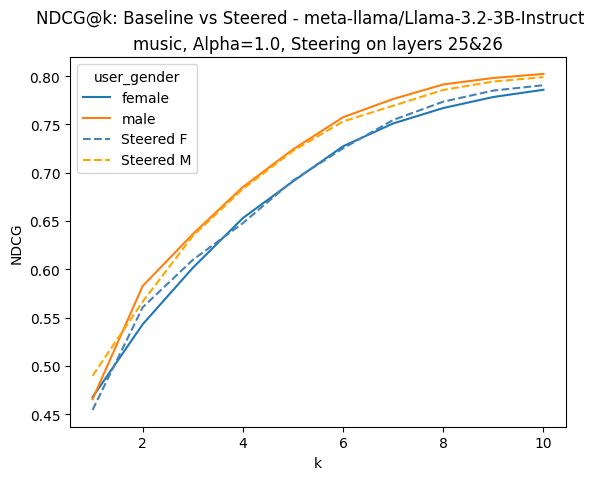

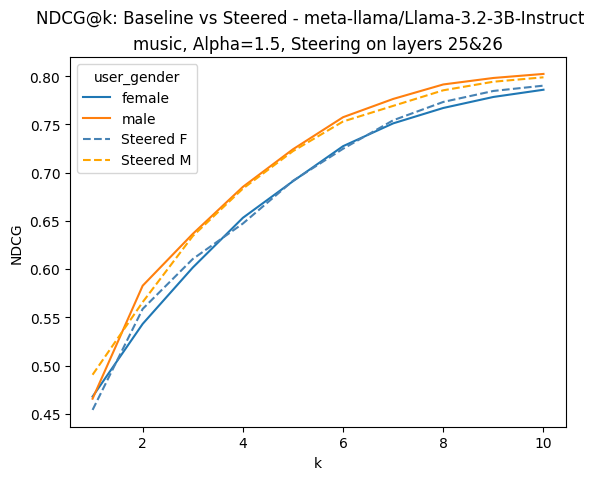

In [79]:
# alpha_list = [1]
for lay in layer_list:
    for a in alpha_list:
    
        # Steered data
        subdf = df_wide[(df_wide.alpha==a) & (df_wide.layer==lay)]
        if not subdf.empty:
            subdf.columns = ['alpha','layer','k','Steered_F','Steered_M']
            ax = bl_df_wide.sort_values('k').plot(x='k', y=['female', 'male'])

            # 2. Plot the reference line from the second DataFrame onto the same 'ax'
            # 'ref_df' is your second dataframe
            subdf.sort_values('k').plot(x='k', y='Steered_F', ax=ax, 
                                        label='Steered F', linestyle='--', color='steelblue')
            subdf.sort_values('k').plot(x='k', y='Steered_M', ax=ax, 
                                        label='Steered M', linestyle='--', color='orange')                             

            plt.ylabel('NDCG')
            plt.suptitle(f'NDCG@k: Baseline vs Steered - {full_model_str}')
            plt.title(f'{item_type}, Alpha={a}, Steering on layers {lay-1}&{lay}')
            plt.show()

In [75]:
foldername = '/Users/jessicakahn/Documents/repos/probing_classifiers/goodreads_data'

with open(os.path.join(foldername,'book_data.json'), 'r') as f:
    book_dict = json.load(f)

In [33]:
title_dict = {k: v['title_without_series'] for k, v in book_dict.items()}


In [59]:
j = 'ab'
j[1] == j[0]

False

In [ ]:
j =

'a'

In [37]:
counter = 0
for k, v in title_dict.items():
    counter +=1
    print(k,v)
    if counter >=5:
        break


5333265 W.C. Fields: A Life on Film
1333909 Good Harbor
7327624 The Unschooled Wizard (Sun Wolf and Starhawk, #1-2)
6066819 Best Friends Forever
287140 Runic Astrology: Starcraft and Timekeeping in the Northern Tradition
